# k-Fold Cross Validation

Tamam, sana **K-Fold Cross Validation**’ı hem basit mantığıyla hem de görselleştirerek anlatayım.
Bu teknik aslında şunu çözer: **Modelin doğruluğunu daha güvenilir ölçmek**.

---

## 📌 Normal (Hold-out) Yöntem

Genelde:

* Veriyi **%80 train**, **%20 test** ayırırsın.
* Modeli %80 ile eğitirsin, %20 ile test edersin.

Sorun:
Eğer o %20 test verisi **tesadüfen çok kolay veya çok zor** ise sonuç güvenilir olmayabilir.

---

## 📌 K-Fold Cross Validation Mantığı

1. Veriyi **K eşit parçaya** böl (ör: K = 5).
   Diyelim elimizde 100 veri var → her parça 20 veri.

2. K tur çalıştır:

   * 1. tur → 1. parça **test**, kalan 4 parça **train**.
   * 2. tur → 2. parça **test**, kalanlar **train**.
   * ...
   * 5. tur → 5. parça **test**, kalanlar **train**.

3. Her turda bir **accuracy** sonucu çıkar.

4. **Ortalama accuracy** alınır → işte bu modelin güvenilir performansı.

---

### 🔍 Örnek:

K = 5, Accuracy sonuçları:

* Fold 1 → %91
* Fold 2 → %89
* Fold 3 → %93
* Fold 4 → %90
* Fold 5 → %92

**Ortalama Accuracy** = (91 + 89 + 93 + 90 + 92) / 5 = **%91**

---

## 📌 Avantajlar

* **Tüm veri** hem eğitim hem test olarak kullanılır → veri israfı yok.
* Sonuçlar tek bir tesadüfi bölünmeye bağlı kalmaz.
* Modelin **genelleme gücünü** daha iyi ölçer.

---

## 📌 Dezavantajlar

* Model **K defa eğitildiği** için yavaştır.
* Çok büyük veri setlerinde hesaplama maliyeti artar.

---

💡 **Püf Noktası**
K genelde:

* **Küçük veri seti** → K=10
* **Büyük veri seti** → K=5 veya K=3
  seçilir.

---

Eğer istersen sana **K-Fold Cross Validation kod örneğini** hem SVM hem de başka modellerle çalışacak şekilde verebilirim, böylece eğitimde gördüğün gibi ama daha açıklamalı olur.
İster misin bu kodu da yazayım?


# Kernel SVM


# Importing the libraries

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Importing the dataset

In [16]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

# Splitting the dataset into the Training set and Test set

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)
#print(X_train)
#print(y_train)
#print(X_test)
#print(y_test)

# Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)
#print(X_train)
#print(X_test)

# Training the Kernel SVM model on the Training set

In [19]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)

SVC(random_state=0)

# Predicting a new result

In [20]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


# Predicting the Test set results

In [21]:
y_pred = classifier.predict(X_test)
#print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

# Making the Confusion Matrix

In [22]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[64  4]
 [ 3 29]]


0.93

# Applying k-Fold Cross Validation

In [23]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 90.33 %
Standard Deviation: 6.57 %


# Visualising the Training set results

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Kernel SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

# Visualising the Test set results

C:\Users\523579\AppData\Local\Temp\ipykernel_34004\3257738180.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


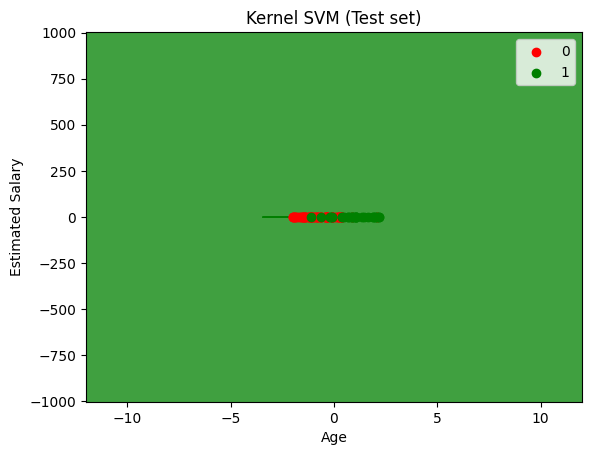

In [14]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Kernel SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()